# 1. Import Libraries

In [117]:
# Core
import math
from collections import Counter
import numpy as np
import pandas as pd
import re, string

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Sklearn – metrics
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, log_loss
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Sklearn – feature extraction & model selection
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import scipy.sparse as sp

# Sklearn – models
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Tabulate (for .to_markdown())
import tabulate

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


# 2. Dataset loading and Basic preprocessing

In [118]:
# load CSV file
df = pd.read_csv('spam_ham_dataset.csv', encoding='latin-1')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [119]:
#Rename and drop unnecessary columns
df = df.rename(columns={'label': 'category', 'label_num': 'spam'})
df = df.drop(columns=['Unnamed: 0'])
df.head()

,category,text,spam
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [120]:
#Remove duplicate rows
print(f'Rows before dropping duplicates: {len(df)}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows after dropping duplicates : {len(df)}')


Rows before dropping duplicates: 5171
Rows after dropping duplicates : 4993


# 3. Feature Engineering

In [121]:
def extract_subject(text: str) -> str:
    """
    Pull the subject line.
    Text format:  'Subject: <subject line>\r\nbody...'
    """
    match = re.match(r'(?is)^\s*subject\s*:\s*(.*?)(?:\r?\n|$)', text)
    return match.group(1).strip() if match else ""
 
 
def extract_body(text: str) -> str:
    """Return everything after the first \r\n (i.e. after the Subject line)."""
    match = re.match(r'(?is)^\s*subject\s*:\s*(.*?)(?:\r?\n|$)', text)
    if not match:
        return text
    return text[match.end():].lstrip("\r\n")


def count_urls(text: str) -> int:
    """
    URLs in this dataset are space-tokenised:  'http : / / domain . com / path'
    Match both that format and standard un-spaced URLs.
    """
    normalized = re.sub(r'\s*([:/.?=&_\-#])\s*', r'\1', text)
    return len(re.findall(r'https?://\S+|www\.\S+', normalized, re.IGNORECASE))

def count_emails(text: str) -> int:
    """
    Count both normal and spaced email formats.
    """
    if not isinstance(text, str):
        return 0
    # Normal emails
    normal = re.findall(
        r'\b[\w.+-]+@[\w.-]+\.\w+\b',
        text,
        flags=re.IGNORECASE
    )
    # Spaced/obfuscated emails
    spaced = re.findall(
        r'\b[\w.+-]+\s*@\s*[\w.-]+\s*\.\s*\w+\b',
        text,
        flags=re.IGNORECASE
    )
    return len(normal) + len(spaced)
 
def text_entropy(text: str) -> float:
    """
    Shannon entropy on character distribution.
    Gibberish / word-salad spam → abnormally high entropy.
    """
    tokens = re.findall(r"[a-z0-9]+", text.lower())
    if not tokens:
        return 0.0
    counts = Counter(tokens)
    total = len(tokens)
    return -sum((c / total) * math.log2(c / total) for c in counts.values())
 
 
def unique_word_ratio(text: str) -> float:
    """
    Unique words / total words.
    Low ratio → repetitive / word-salad spam.
    """
    words = re.findall(r"[a-zA-Z0-9']+", text.lower())
    return len(set(words)) / len(words) if words else 0.0
 
 
def obfuscation_score(text: str) -> int:
    """
    Count characters spammers substitute to dodge keyword filters:
    backtick apostrophes ( we ` re ), pipes, tildes, carets.
    """
    return len(re.findall(r'[`|~^]', text)) + len(re.findall(r'([!$%#*@])\1{1,}', text))
 
 
def forward_depth(text: str) -> int:
    """
    Count forwarding / reply markers.
    Deep forwards → very likely internal ham.
    """
    return len(re.findall(
        r'(forwarded by|original message|^\s*re\s*:|^\s*fw\s*:)'
        , text, re.IGNORECASE | re.MULTILINE
    ))

In [122]:
#  FEATURE EXTRACTION 

# ── Intermediary columns (dropped at end) ────────────────────
df['_subject'] = df['text'].apply(extract_subject)
df['_body']    = df['text'].apply(extract_body)

# ── Basic length features ────────────────────
df['char_count']          = df['text'].apply(len)
df['word_count']          = df['text'].apply(lambda t: len(t.split()))
df['line_count']          = df['text'].apply(lambda t: len(t.splitlines()))
df['avg_word_length']     = df['text'].apply(lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0)

# ── Ratio features ───────────────────────────
df['uppercase_ratio']     = df['text'].apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
df['digit_ratio']         = df['text'].apply(lambda t: sum(1 for c in t if c.isdigit()) / max(len(t), 1))
# df['has_numbers']         = df['text'].apply(lambda t: bool(re.search(r'\d', t))).astype(int)   # DROPPED
df['unique_word_ratio']   = df['text'].apply(unique_word_ratio)  

# ── Symbol / punctuation counts ─────────────
df['has_currency_symbol'] = df['text'].apply(lambda t: bool(re.search(r'[$£€¥]', t)))
df['exclamation_count']   = df['text'].apply(lambda t: t.count('!'))
df['question_count']      = df['text'].apply(lambda t: t.count('?'))
df['special_char_count']  = df['text'].apply(lambda t: sum(1 for c in t if c in '!@#$%^&*()_+-=[]{}|;:,.<>?/~`'))
df['obfuscation_score']   = df['text'].apply(obfuscation_score)

# ── Link / contact patterns ──────────────────
df['url_count']           = df['text'].apply(count_urls)

df['email_count']         = df['text'].apply(count_emails)
df['phone_count']         = df['text'].apply(
    lambda t: len(re.findall(
        r'\b(\+?\d{1,3}[\s\-.]?)?\(?\d{3}\)?[\s\-.]?\d{3,4}[\s\-.]?\d{4}\b', t
    ))
)
df['long_digit_seq_count']= df['text'].apply(lambda t: len(re.findall(r'\b\d{4,}\b', t)))


# ── Structure / header features ──────────────
df['subject_word_count']      = df['_subject'].apply(lambda s: len(s.split()) if s else 0)
df['subject_char_count']      = df['_subject'].apply(len)
df['subject_exclamation']     = df['_subject'].apply(lambda s: s.count('!') if s else 0)

# ── Structure features ───────────────────────────────────────
df['forward_depth']       = df['text'].apply(forward_depth)

# ── Entropy ──────────────────────────────────
df['text_entropy']        = df['text'].apply(text_entropy)

# ── Drop internal helper columns ─────────────────────────────
df.drop(columns=['_subject', '_body'], inplace=True)


# ── Drop the temporary helper column ─────────
#df.drop(columns=['subject_line'], inplace=True)

#  FEATURE SUMMARY
feature_cols = [c for c in df.columns if c not in ['text', 'category', 'spam']]
print(f"Total engineered features : {len(feature_cols)}")
print(f"Feature list              : {feature_cols}")
print(df[feature_cols].describe().T[['mean','std','min','max']].round(4))

df.head()

Total engineered features : 21
Feature list              : ['char_count', 'word_count', 'line_count', 'avg_word_length', 'uppercase_ratio', 'digit_ratio', 'unique_word_ratio', 'has_currency_symbol', 'exclamation_count', 'question_count', 'special_char_count', 'obfuscation_score', 'url_count', 'email_count', 'phone_count', 'long_digit_seq_count', 'subject_word_count', 'subject_char_count', 'subject_exclamation', 'forward_depth', 'text_entropy']
                           mean        std      min         max
char_count            1069.4264  1547.8634  11.0000  32258.0000
word_count             232.2676   340.2420   1.0000   8862.0000
line_count              19.6910    27.0555   1.0000    399.0000
avg_word_length          3.5962     0.8731   1.3296     10.6310
uppercase_ratio          0.0034     0.0048   0.0000      0.0909
digit_ratio              0.0517     0.0508   0.0000      0.4086
unique_word_ratio        0.7105     0.1747   0.0947      1.0000
exclamation_count        0.7206     2.08

,category,text,spam,char_count,word_count,line_count,avg_word_length,uppercase_ratio,digit_ratio,unique_word_ratio,...,obfuscation_score,url_count,email_count,phone_count,long_digit_seq_count,subject_word_count,subject_char_count,subject_exclamation,forward_depth,text_entropy
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327,67,6,3.820896,0.003058,0.030581,0.907407,...,0,0,0,0,1,7,33,0,0,5.539241
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,23,3,3.173913,0.010309,0.092784,0.812500,...,0,0,0,0,1,7,28,0,0,3.625000
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,550,10,3.574545,0.000396,0.005547,0.455670,...,0,1,0,0,0,2,12,0,0,7.123796
3,spam,"Subject: photoshop , windows , office . cheap ...",1,414,48,10,7.416667,0.002415,0.000000,1.000000,...,0,0,0,0,0,10,52,0,0,5.459432
4,ham,Subject: re : indian springs\r\nthis deal is t...,0,336,70,5,3.757143,0.002976,0.000000,0.769231,...,0,0,0,0,0,4,19,0,0,5.472274


## 4. Data Cleaning

In [123]:
# ── Bundled stopword list (no download needed) ───────────────
# We ship a fixed English stopword set instead of calling
# nltk.download() so the script works in any environment.
_ENGLISH_STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up',
    'down','in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','both','each',
    'few','other','some','such','no','nor','not','only','same','so','than',
    'too','very','s','t','can','will','d','ll','m','o','re','ve','y',
    'ain','aren','couldn','didn','doesn','hadn','hasn','haven','isn','ma',
    'mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn',
    'would','could','shall','might','must','ought','also','upon','within',
    'without','along','across','behind','beyond','beside','since','although',
    'however','therefore','thus','moreover','furthermore','meanwhile',
    'nevertheless','instead','otherwise','yet','still','already','even',
    'whether','either','neither','except','per','via','vs','etc','eg','ie', 
}
 
# Keep words that carry spam signal — DO NOT remove from vocabulary.
_SPAM_WORDS_TO_KEEP = {
    'free', 'win', 'winner', 'won', 'prize', 'offer', 'buy', 'sale',
    'discount', 'cheap', 'now', 'urgent', 'limited', 'click', 'guarantee',
    'money', 'cash', 'earn', 'profit', 'over', 'only', 'best', 'get', 'need', 'new', 'more', 'just',
}
 
CUSTOM_STOPWORDS = _ENGLISH_STOPWORDS - _SPAM_WORDS_TO_KEEP
stemmer = PorterStemmer()
 
 
def _base_clean(text: str) -> str:
    """
    Cleaning pipeline tuned for the Enron email dataset.
    Keeps spam-indicative tokens like urltoken, emailtoken, numtoken, currencytoken.
    """
    
    if not isinstance(text, str):
        return ""
 
    # 1. Lowercase
    text = text.lower()

    # 2. Collapse spaced punctuation used in this dataset
    #    Example: "http : / / site . com" -> "http://site.com"
    text = re.sub(r'\s*([:/@.,!?$%\-])\s*', r'\1', text)
 
    # 3. Strip Subject header line (must happen before step 3)
    text = re.sub(r'subject\s*:.*?(?:\r\n|\n)', '', text, flags=re.IGNORECASE)
 
    # 4. Normalise line endings
    text = text.replace('\r\n', ' ').replace('\n', ' ').replace('\r', ' ')
 
    # 5. Replace URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' urltoken ', text)
 
    # 6. Replace email addresses
    text = re.sub(r'\b[\w.+-]+@[\w.-]+\.\w+\b', ' emailtoken ', text)
 
    # 7. Replace currency values
    text = re.sub(r'[$£€¥]\s*\d[\d,\.]*', ' currencytoken ', text)
 
    # 8. Replace numbers
    text = re.sub(r'\b\d+(?:[.,]\d+)*\b', ' ', text)
 
    # 9. Remove non-alpha characters
    text = re.sub(r'[^a-z\s]', ' ', text)
 
    # 10. Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()
 
    return text


def clean_email_stem(text: str) -> str:
    text = _base_clean(text)
    tokens = [
        stemmer.stem(w)
        for w in text.split()
        if w not in CUSTOM_STOPWORDS and len(w) > 1
    ]
    return ' '.join(tokens)


def clean_email_no_stem(text: str) -> str:
    text = _base_clean(text)
    tokens = [
        w for w in text.split()
        if w not in CUSTOM_STOPWORDS and len(w) > 1
    ]
    return ' '.join(tokens)


df['clean_text_stem'] = df['text'].apply(clean_email_stem)
df['clean_text_no_stem'] = df['text'].apply(clean_email_no_stem)

df[['clean_text_stem', 'clean_text_no_stem']].head()


,clean_text_stem,clean_text_no_stem
0,follow note gave monday preliminari flow data ...,follow note gave monday preliminary flow data ...
1,see attach file hplnol xl hplnol xl,see attached file hplnol xls hplnol xls
2,ho ho ho around most wonder time year neon lea...,ho ho ho around most wonderful time year neon ...
3,abas darer prudent fortuit undergon lightheart...,abasements darer prudently fortuitous undergon...
4,deal book teco pvr revenu understand teco just...,deal book teco pvr revenue understanding teco ...


## 5. Exploratory Data Analysis (EDA)

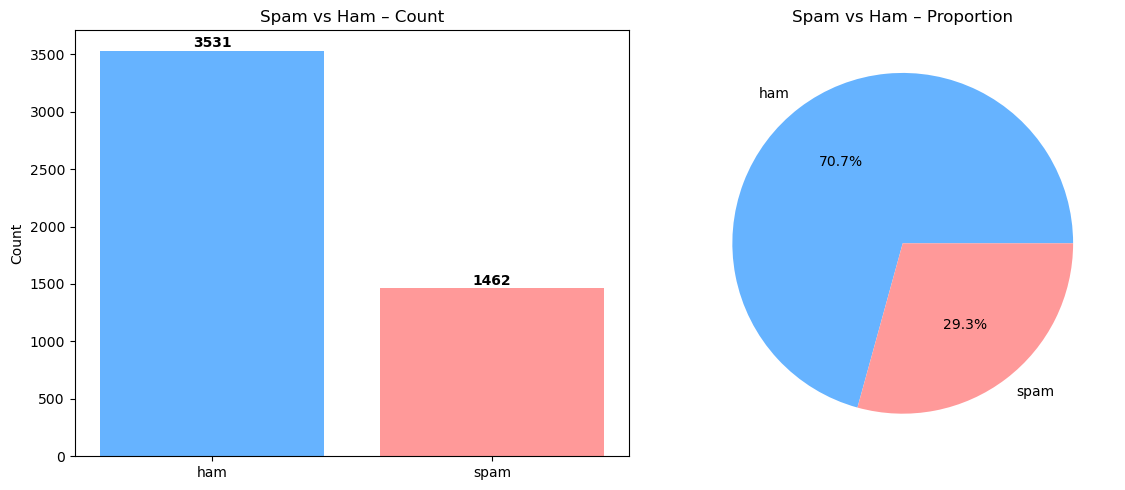


Imbalance ratio: 2.4:1 (ham:spam)


In [124]:
# 5.1  Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['category'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#66b3ff', '#ff9999'])
for i, (cat, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 30, str(cnt), ha='center', fontweight='bold')
axes[0].set_title('Spam vs Ham – Count')
axes[0].set_ylabel('Count')

# Pie chart
counts.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], ax=axes[1])
axes[1].set_title('Spam vs Ham – Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {counts['ham']/counts['spam']:.1f}:1 (ham:spam)")


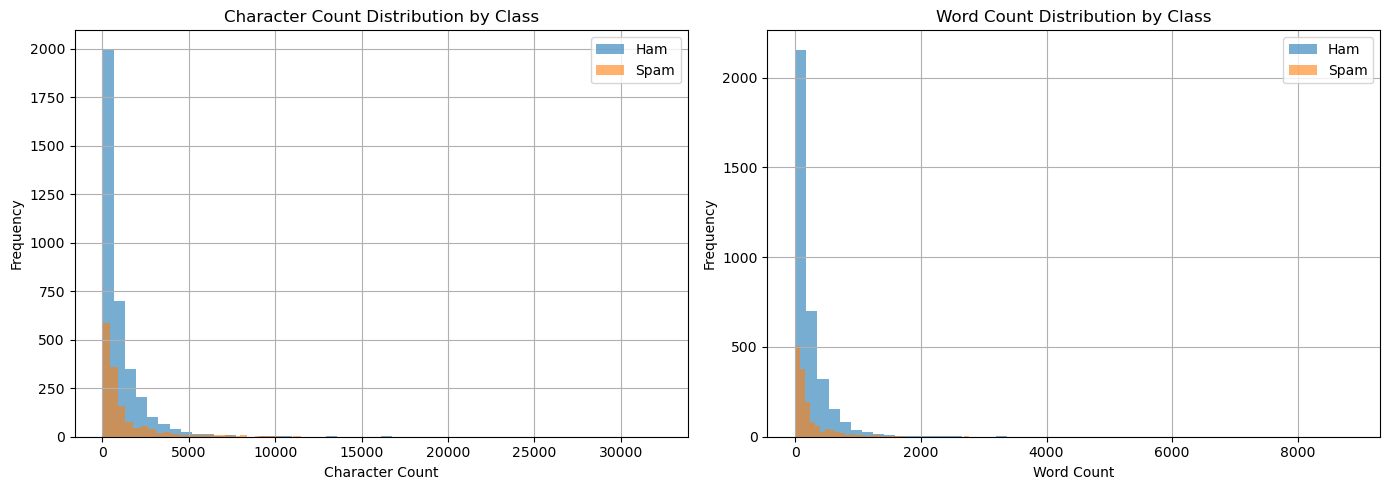

|   spam |   count |     mean |     std |   min |    25% |   50% |    75% |   max |
|-------:|--------:|---------:|--------:|------:|-------:|------:|-------:|------:|
|      0 |    3531 |  994.939 | 1402.79 |    18 | 241    |   538 | 1253.5 | 32258 |
|      1 |    1462 | 1249.33  | 1840.11 |    11 | 304.25 |   589 | 1305   | 22073 |


In [125]:
# 5.2.1 Message length distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'char_count', 'Character Count'),
    (axes[1], 'word_count', 'Word Count')
]:
    df[df['spam'] == 0][col].hist(bins=50, alpha=0.6, label='Ham', ax=ax)
    df[df['spam'] == 1][col].hist(bins=50, alpha=0.6, label='Spam', ax=ax)
    ax.set_title(f'{title} Distribution by Class')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

print(df.groupby('spam')['char_count'].describe().to_markdown())

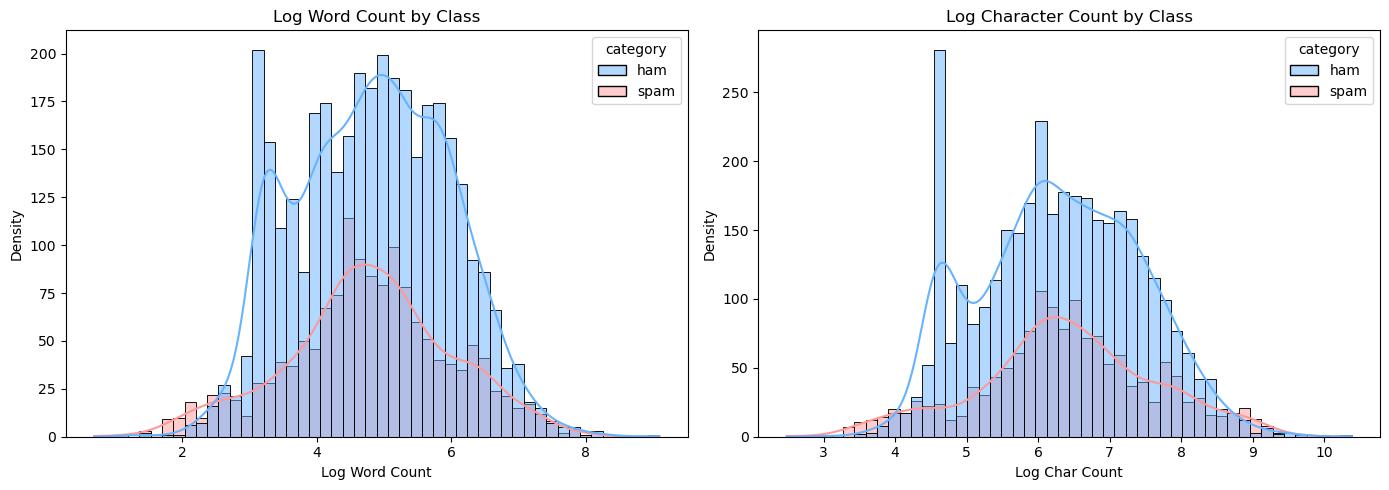

In [126]:
# 5.2.2  Message length distribution by class
df['log_word_count'] = np.log1p(df['word_count'])
df['log_char_count'] = np.log1p(df['char_count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], 'log_word_count', 'Log Word Count by Class'),
    (axes[1], 'log_char_count', 'Log Character Count by Class'),
]:
    sns.histplot(data=df, x=col, hue='category', ax=ax, bins=50, kde=True, palette=['#66b3ff','#ff9999'])
    ax.set_title(title)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

In [127]:
df.columns

Index(['category', 'text', 'spam', 'char_count', 'word_count', 'line_count',
       'avg_word_length', 'uppercase_ratio', 'digit_ratio',
       'unique_word_ratio', 'has_currency_symbol', 'exclamation_count',
       'question_count', 'special_char_count', 'obfuscation_score',
       'url_count', 'email_count', 'phone_count', 'long_digit_seq_count',
       'subject_word_count', 'subject_char_count', 'subject_exclamation',
       'forward_depth', 'text_entropy', 'clean_text_stem',
       'clean_text_no_stem', 'log_word_count', 'log_char_count'],
      dtype='object')

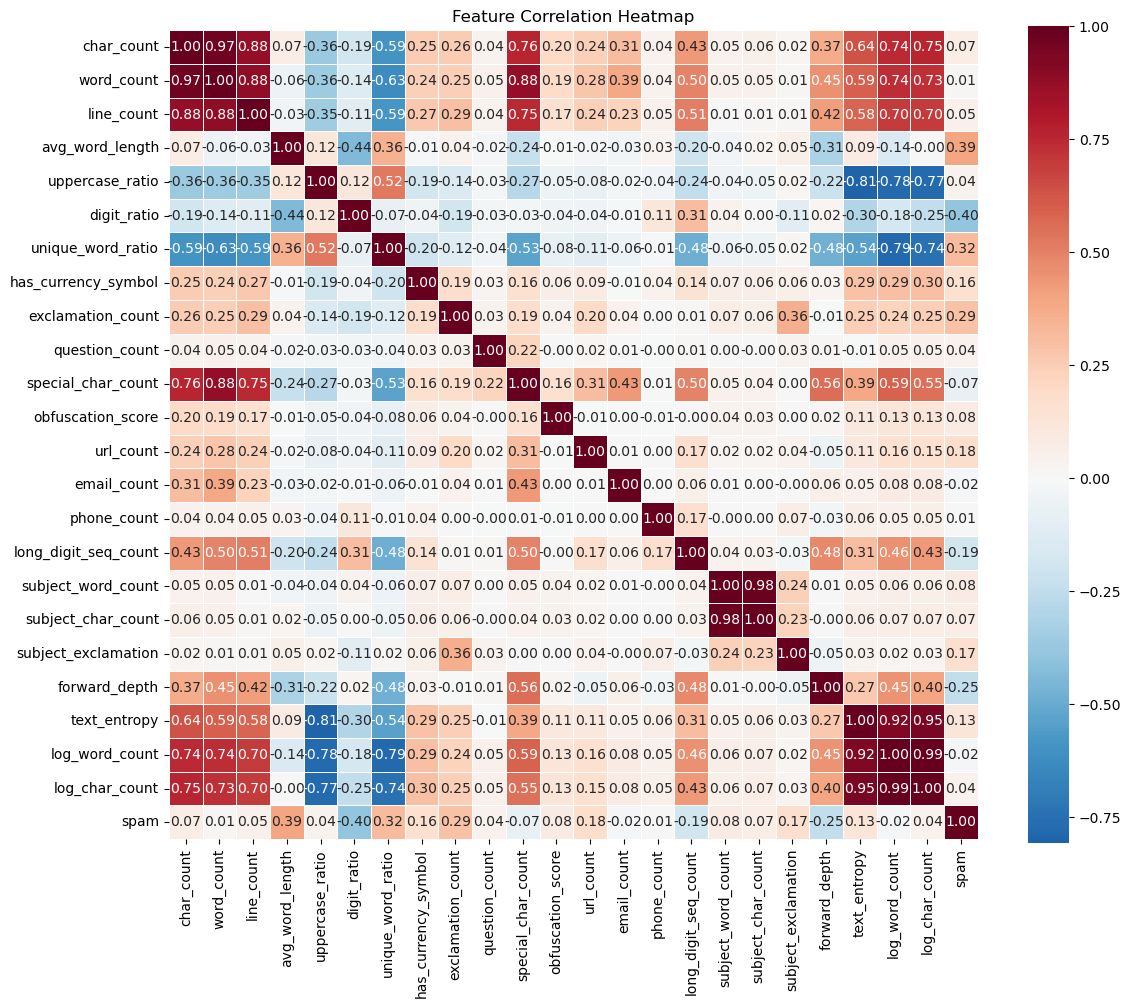

In [128]:
# 5.3  Correlation heatmap of engineered features vs target 
eng_cols = [  # Engineered feature columns (exclude 'text', 'category', 'clean_text_stem', 'clean_text_no_stem')
       'char_count', 'word_count', 'line_count',
       'avg_word_length', 'uppercase_ratio', 'digit_ratio',
       'unique_word_ratio', 'has_currency_symbol', 'exclamation_count',
       'question_count', 'special_char_count', 'obfuscation_score',
       'url_count', 'email_count', 'phone_count', 'long_digit_seq_count',
       'subject_word_count', 'subject_char_count', 'subject_exclamation','forward_depth', 'text_entropy', 'log_word_count',
       'log_char_count']

corr_df = df[eng_cols + ['spam']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


In [129]:
# 5.4  Top features correlated with spam
corr_with_spam = corr_df['spam'].drop('spam').sort_values(ascending=False)
print("Feature correlation with spam label:")
print(corr_with_spam.to_markdown())

Feature correlation with spam label:
|                      |        spam |
|:---------------------|------------:|
| avg_word_length      |  0.393489   |
| unique_word_ratio    |  0.319107   |
| exclamation_count    |  0.291121   |
| url_count            |  0.17663    |
| subject_exclamation  |  0.173606   |
| has_currency_symbol  |  0.161861   |
| text_entropy         |  0.131145   |
| obfuscation_score    |  0.0843386  |
| subject_word_count   |  0.075105   |
| char_count           |  0.074794   |
| subject_char_count   |  0.0719793  |
| line_count           |  0.0495853  |
| question_count       |  0.0417708  |
| log_char_count       |  0.0417426  |
| uppercase_ratio      |  0.0365651  |
| word_count           |  0.0126858  |
| phone_count          |  0.00946583 |
| email_count          | -0.0174449  |
| log_word_count       | -0.0174992  |
| special_char_count   | -0.0734378  |
| long_digit_seq_count | -0.187811   |
| forward_depth        | -0.247779   |
| digit_ratio          | -0

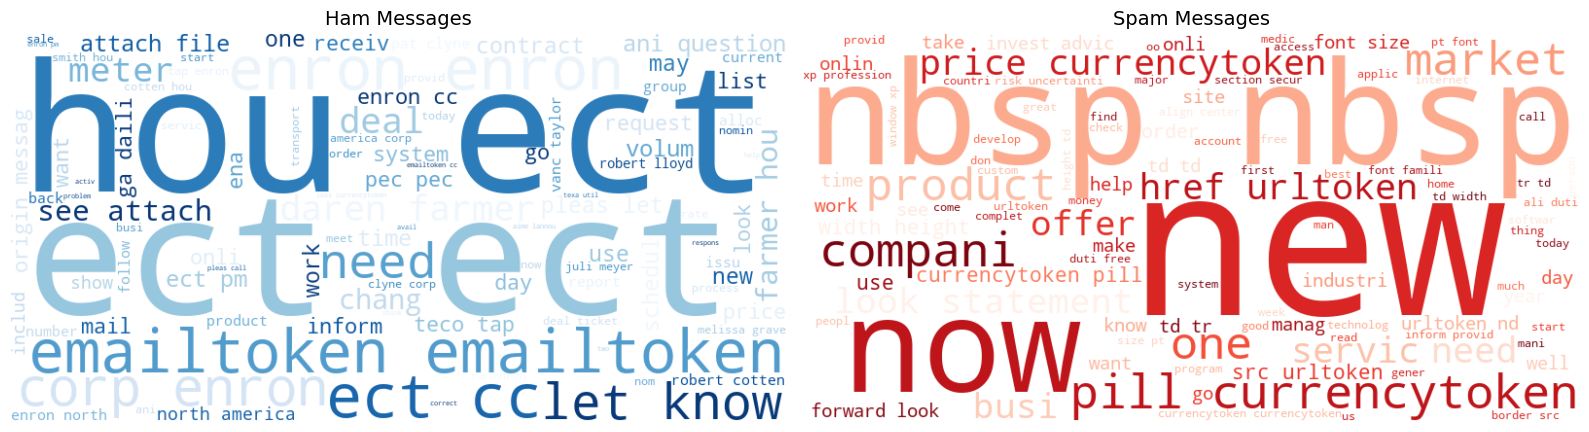

In [130]:
# 5.5  Word clouds for spam vs ham
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, cmap in [
    (axes[0], 0, 'Ham Messages', 'Blues'),
    (axes[1], 1, 'Spam Messages', 'Reds')
]:
    text = ' '.join(df[df['spam'] == label]['clean_text_stem'].values)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


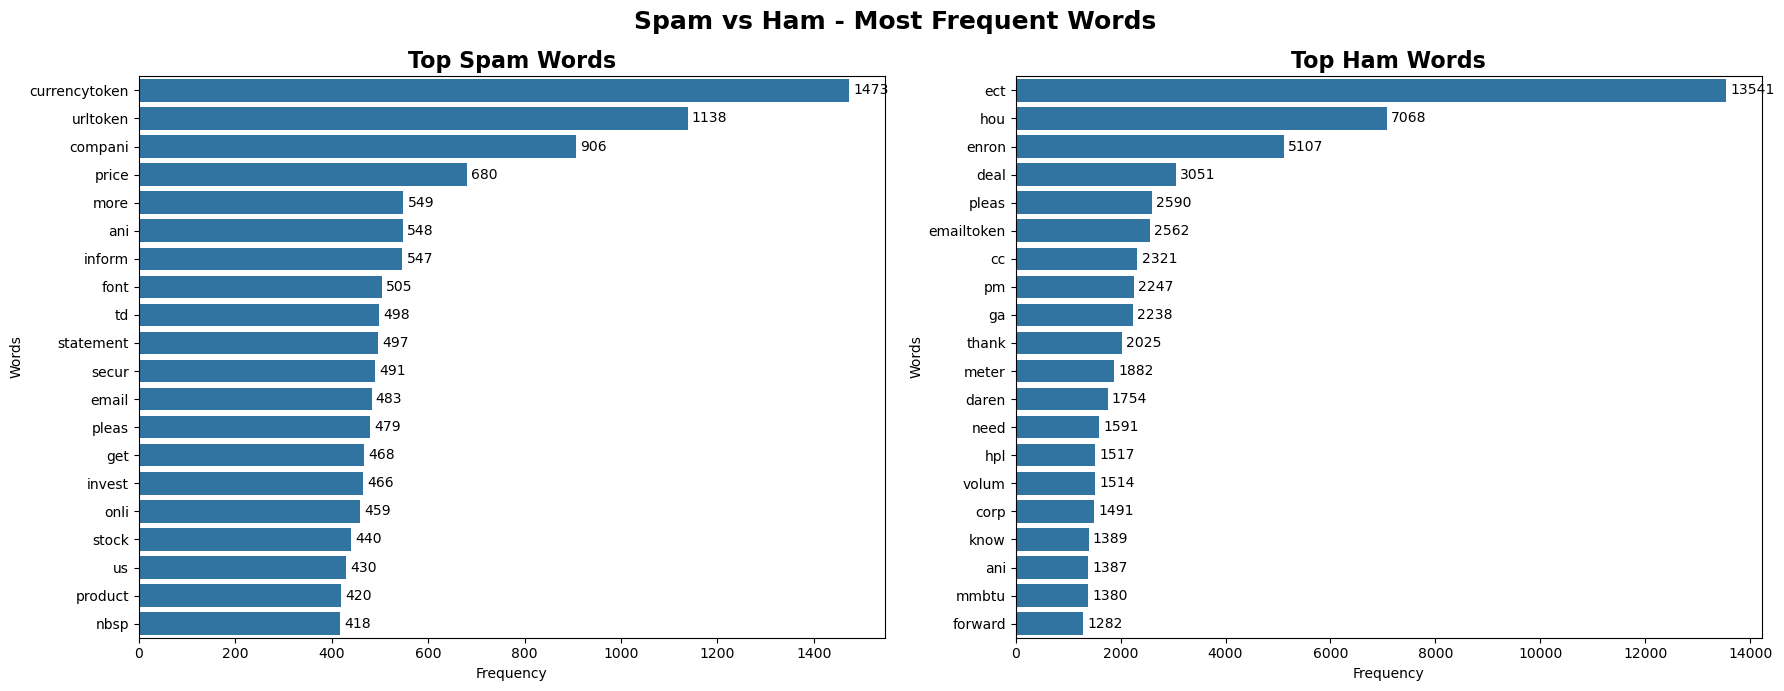

In [ ]:
# 5.6  TOP WORD ANALYSIS - SPAM vs HAM

# Build corpus
spam_text = ' '.join(df[df['spam'] == 1]['clean_text_stem'])
ham_text  = ' '.join(df[df['spam'] == 0]['clean_text_stem'])
spam_words = Counter(spam_text.split())
ham_words  = Counter(ham_text.split())

# Convert to dataframe
top_n = 20
spam_df = pd.DataFrame(
    spam_words.most_common(top_n),
    columns=['word', 'count']
)
spam_df['type'] = 'Spam'
ham_df = pd.DataFrame(
    ham_words.most_common(top_n),
    columns=['word', 'count']
)
ham_df['type'] = 'Ham'
combined_df = pd.concat([spam_df, ham_df], ignore_index=True)


# SIDE-BY-SIDE COMPARISON PLOT
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Spam plot
sns.barplot(
    data=spam_df,
    x='count',
    y='word',
    ax=axes[0]
)
axes[0].set_title(
    'Top Spam Words',
    fontsize=16,
    fontweight='bold'
)
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Ham plot
sns.barplot(
    data=ham_df,
    x='count',
    y='word',
    ax=axes[1]
)
axes[1].set_title(
    'Top Ham Words',
    fontsize=16,
    fontweight='bold'
)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Words')
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.suptitle(
    'Spam vs Ham - Most Frequent Words',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()